# Lasso regrssion to identifity Dolastatin-10 drug sensitivity predictors
in all CCLE cell lines

For description of the drug sensitivity    
https://www.sciencedirect.com/science/article/pii/S2211124724005035

In [1]:
required.packages <- c( 'caret', 'data.table', 'ggplot2', 'glmnet', 
                       'gower', 'glue', 'rio', 'tidyr', 'iml', 'lime', 'ggrepel', 'ggpmisc', 'dplyr')

new.packages <- setdiff(required.packages, rownames(installed.packages()))

if(length(new.packages) > 0){
    
    install.packages(new.packages)

}

sapply(required.packages, function(pkg) {suppressPackageStartupMessages(require(pkg, character.only = TRUE))})
# if installed.packages()

caret data.table    ggplot2     glmnet      gower       glue        rio 
      TRUE       TRUE       TRUE       TRUE       TRUE       TRUE       TRUE 
     tidyr        iml       lime    ggrepel    ggpmisc      dplyr 
      TRUE       TRUE       TRUE       TRUE       TRUE       TRUE

In [27]:
# settings
data_dir <- '/datanew/DepMap'

data_time <- '24Q2'
data_dir <- glue('{data_dir}/{data_time}')
# Camptothecin
drugs <- c('DOLASTATIN-10')
drug_pipes <- paste(drugs, collapse = '|')
drug_pipes

[1] "DOLASTATIN-10"

In [29]:
logFC_mat <- import(glue('{data_dir}/Repurposing_Public_24Q2_Extended_Primary_Data_Matrix.csv'))
row.names(logFC_mat) <- logFC_mat$V1
logFC_mat$V1 <- NULL
# logFC_mat$V1 <- gsub('BRD:', '', logFC_mat$V1)

In [30]:
logFC_mat[1:3, 1:6]

,ACH-000001,ACH-000002,ACH-000004,ACH-000005,ACH-000006,ACH-000007
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BRD:BRD-A00047421-001-01-7,-1.20728146,-4.231563,-3.860672,-2.271411,0.2778328,-4.01128501
BRD:BRD-A00055058-001-01-0,0.51574339,NA,NA,NA,NA,0.19687776
BRD:BRD-A00077618-236-07-6,-0.01557664,NA,NA,NA,NA,-0.09573033


In [47]:
trt_meta <- import(glue('{data_dir}/Repurposing_Public_24Q2_Extended_Primary_Compound_List.csv'))

drug_ids <- trt_meta %>% filter(grepl(drug_pipes, Drug.Name, ignore.case=TRUE)) %>% pull(IDs)
logFC_mat_sub <- t(logFC_mat[drug_ids, ]) %>% as.data.frame()

names(logFC_mat_sub)[1] <- 'logFC'

In [48]:
head(logFC_mat_sub)

,logFC
,<dbl>
ACH-000001,NA
ACH-000002,NA
ACH-000004,NA
ACH-000005,NA
ACH-000006,NA
ACH-000007,-4.157717


In [37]:
pheno <- import(glue('{data_dir}/Model.csv'))
head(pheno, 2)

,ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,LegacyMolecularSubtype,⋯,EngineeredModel,TissueOrigin,ModelDerivationMaterial,PublicComments,CCLEName,HCMIID,WTSIMasterCellID,SangerModelID,COSMICID,DateSharedIndbGaP
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<lgl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<lgl>
1,ACH-000001,PT-gj46wT,NIH:OVCAR-3,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,HGSOC,,⋯,,NA,,,NIHOVCAR3_OVARY,,2201,SIDM00105,905933,NA
2,ACH-000002,PT-5qa3uk,HL-60,HL60,AML,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,AML,,⋯,,NA,,,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,,55,SIDM00829,905938,NA


In [46]:
pheno.select <- pheno %>% select('ModelID', CellLineName, OncotreePrimaryDisease)
head(pheno.select, 2)

,ModelID,CellLineName,OncotreePrimaryDisease
,<chr>,<chr>,<chr>
1,ACH-000001,NIH:OVCAR-3,Ovarian Epithelial Tumor
2,ACH-000002,HL-60,Acute Myeloid Leukemia


In [58]:
logfc.pheno <- merge(logFC_mat_sub, pheno.select, by.x = 'row.names', by.y = 'ModelID')
row.names(logfc.pheno) <- logfc.pheno$Row.names
logfc.pheno$Row.names <- NULL
head(logfc.pheno, 2)

,logFC,CellLineName,OncotreePrimaryDisease
,<dbl>,<chr>,<chr>
ACH-000001,NA,NIH:OVCAR-3,Ovarian Epithelial Tumor
ACH-000002,NA,HL-60,Acute Myeloid Leukemia


In [55]:
# RNAseq TPM gene expression data for all genes using RSEM. Log2 transformed, using a pseudo-count of 1
exp_tpm = import(glue('{data_dir}/OmicsExpressionProteinCodingGenesTPMLogp1.csv'))

rownames(exp_tpm) <- exp_tpm$V1
exp_tpm$V1 <- NULL

colnames(exp_tpm) <- gsub(' \\(', '_', colnames(exp_tpm))
colnames(exp_tpm) <- gsub('\\)', '', colnames(exp_tpm))
colnames(exp_tpm) <- sapply(strsplit(colnames(exp_tpm), '_'), '[', 1)

In [56]:
exp_tpm[1:3, 1:6]

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
ACH-001113,4.331992,0.0000000,7.364660,2.792855,4.471187,0.02856915
ACH-001289,4.567424,0.5849625,7.106641,2.543496,3.504620,0.00000000
ACH-001339,3.150560,0.0000000,7.379118,2.333424,4.228049,0.05658353


In [57]:
dim(exp_tpm)

[1]  1517 19193

In [69]:
options(warn = -1)
cor.res <- NULL

    
for(i in 1:length(colnames(exp_tpm))){

    gene <- colnames(exp_tpm)[i]

    exp_df <- exp_tpm[, gene, drop = F]
    df <- merge(logfc.pheno, exp_df, by = 'row.names') %>% select(logFC, !!gene,) %>% na.omit()


    Y <- as.vector(df[, 'logFC'])
    x <- as.vector(df[, gene])
    n <- length(x)
    p <- cor.test(x,Y, method = 'spearman')$p.value


    rho <- cor(x,Y, method = 'spearman')

    res <- data.frame(gene = gene, Rho = rho, pValue = p, N = n)
    cor.res <- rbind(cor.res, res)

}

In [72]:
cor.res %>% arrange(pValue) %>% head()

,gene,Rho,pValue,N
,<chr>,<dbl>,<dbl>,<int>
1,SLC34A3,0.2648672,3.475505e-10,544
2,RNF224,0.2546515,1.686982e-09,544
3,PPL,0.2301651,5.665924e-08,544
4,LIPH,0.2255523,1.053144e-07,544
5,CAPS,0.2252870,1.090923e-07,544
6,KIAA1522,0.2250746,1.122125e-07,544


In [73]:

cutoff <- 200
# res.sub <- cor.res %>% filter(inhibitor == inhibitor) %>% arrange(pValue) %>% head(300)
res.sub <- cor.res 
res.sub$p.adj <- p.adjust(res.sub$pValue, method = 'BH')
# res.sub <- res.sub %>% arrange(p.adj) %>% filter(p.adj < 0.05) %>% head(100)
res.sub <- res.sub %>% arrange(p.adj) %>% filter(p.adj < 0.05) %>% head(cutoff)
# head(res.sub, 10)


In [81]:
head(res.sub, 2)

,gene,Rho,pValue,N,p.adj
,<chr>,<dbl>,<dbl>,<int>,<dbl>
1,SLC34A3,0.2648672,3.475505e-10,544,6.668103e-06
2,RNF224,0.2546515,1.686982e-09,544,1.618322e-05


In [82]:
dim(res.sub)

[1] 200   5

In [79]:
plot_df <- cor.res 
plot_df$p.adj <- p.adjust(plot_df$pValue, method = 'BH')
plot_df$hgnc <- sapply(strsplit(plot_df$gene, '_'), '[', 1)
plot_df$label <- ifelse((-log10(plot_df$p.adj) > 4), plot_df$gene, NA)

h_line_value <-  plot_df %>% arrange(p.adj) %>% head(cutoff) %>% pull(p.adj)
h_line_value <- h_line_value[length(h_line_value)]
h_line_value <- -log10(h_line_value)

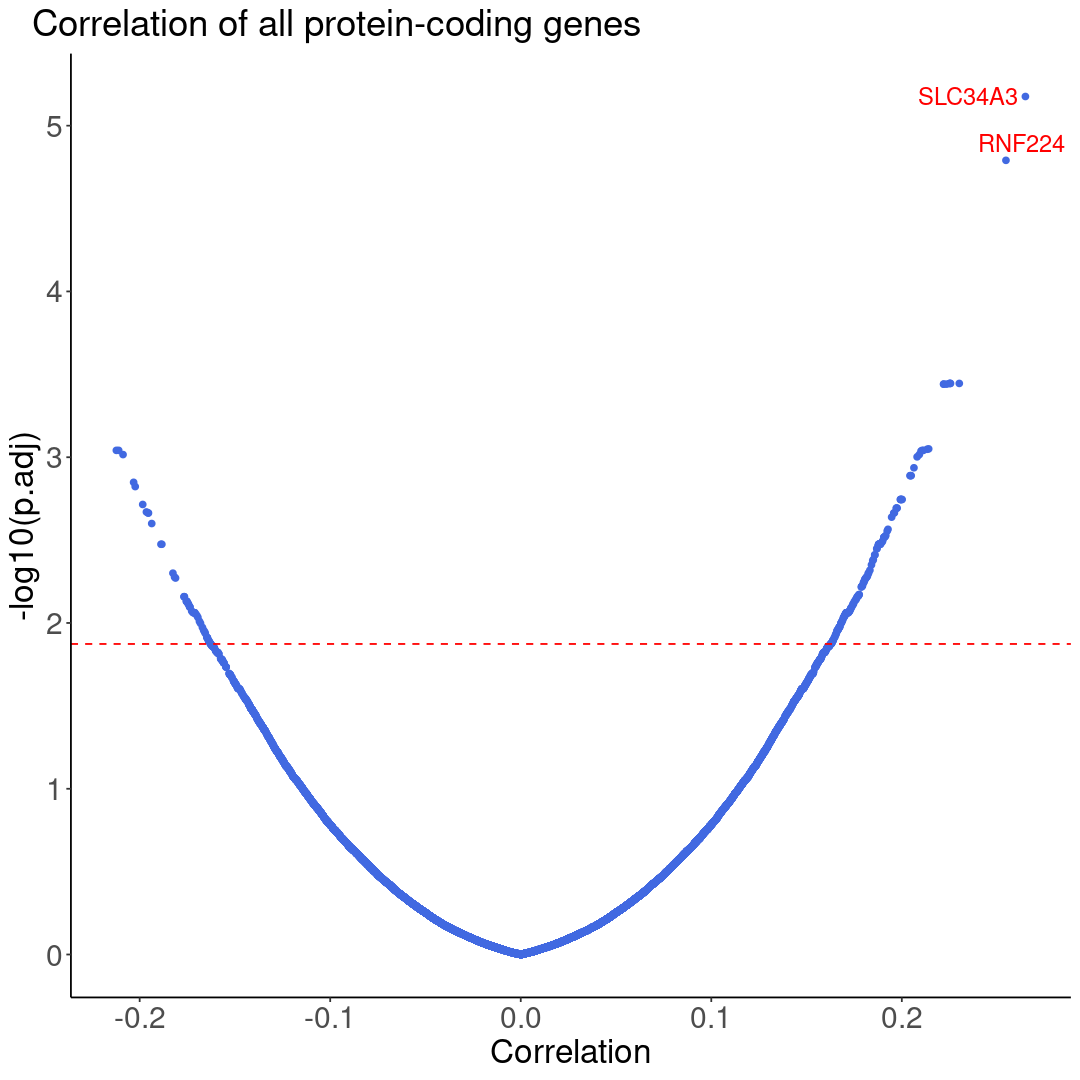

In [80]:
options(repr.plot.width = 9, repr.plot.height = 9)
ggplot(data = plot_df, aes(x = Rho, y = -log10(p.adj))) +
geom_point(colour = 'royalblue', size = 1.5) +
geom_hline(yintercept = h_line_value, linetype='dashed', col = 'red') +
geom_text_repel(aes(label = label), size = 5, color = 'red') +
labs(x= 'Correlation', 
     title = glue('Correlation of all protein-coding genes')) +
theme_classic() +
    theme(axis.text.x = element_text(size = 18),
        axis.text.y = element_text(size = 18),  
        axis.title.x = element_text( size = 20),
        axis.title.y = element_text(size = 20), 
          plot.title = element_text(size=22, hjust = -0.1))

In [83]:
gene_list <- res.sub$gene
exp_lasso <- exp_tpm[, gene_list]
lasso_df <- merge(logFC_mat_sub, exp_lasso, by = 'row.names')
lasso_df <- na.omit(lasso_df)
# reset row.names
row.names(lasso_df) <- NULL
cat('There are ', dim(lasso_df)[1], ' cell lines in the data')

There are  544  cell lines in the data

In [84]:
head(lasso_df, 2)

,Row.names,logFC,SLC34A3,RNF224,CAPS,PPL,KIAA1522,LIPH,PCDH1,BCL2L1,⋯,DAPP1,EPS8L1,SPOCK2,HSPE1,LYNX1,MRPL18,MCOLN2,TRIM27,RGS6,GJB4
,<I<chr>>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ACH-000007,-4.157717,0.22650853,0.7990873,2.324811,5.0729633,5.213736,4.220330,5.238023,6.578788,⋯,1.17632277,4.982309,0.04264434,9.717848,0.01435529,6.093814,2.130931,5.090430,0.641546,2.843984
2,ACH-000008,-2.232895,0.07038933,0.2016339,5.926948,0.5459684,2.757023,1.104337,5.012569,5.659068,⋯,0.05658353,2.310340,0.18903382,10.253375,0.95605665,6.140165,3.675816,5.816344,0.000000,0.000000


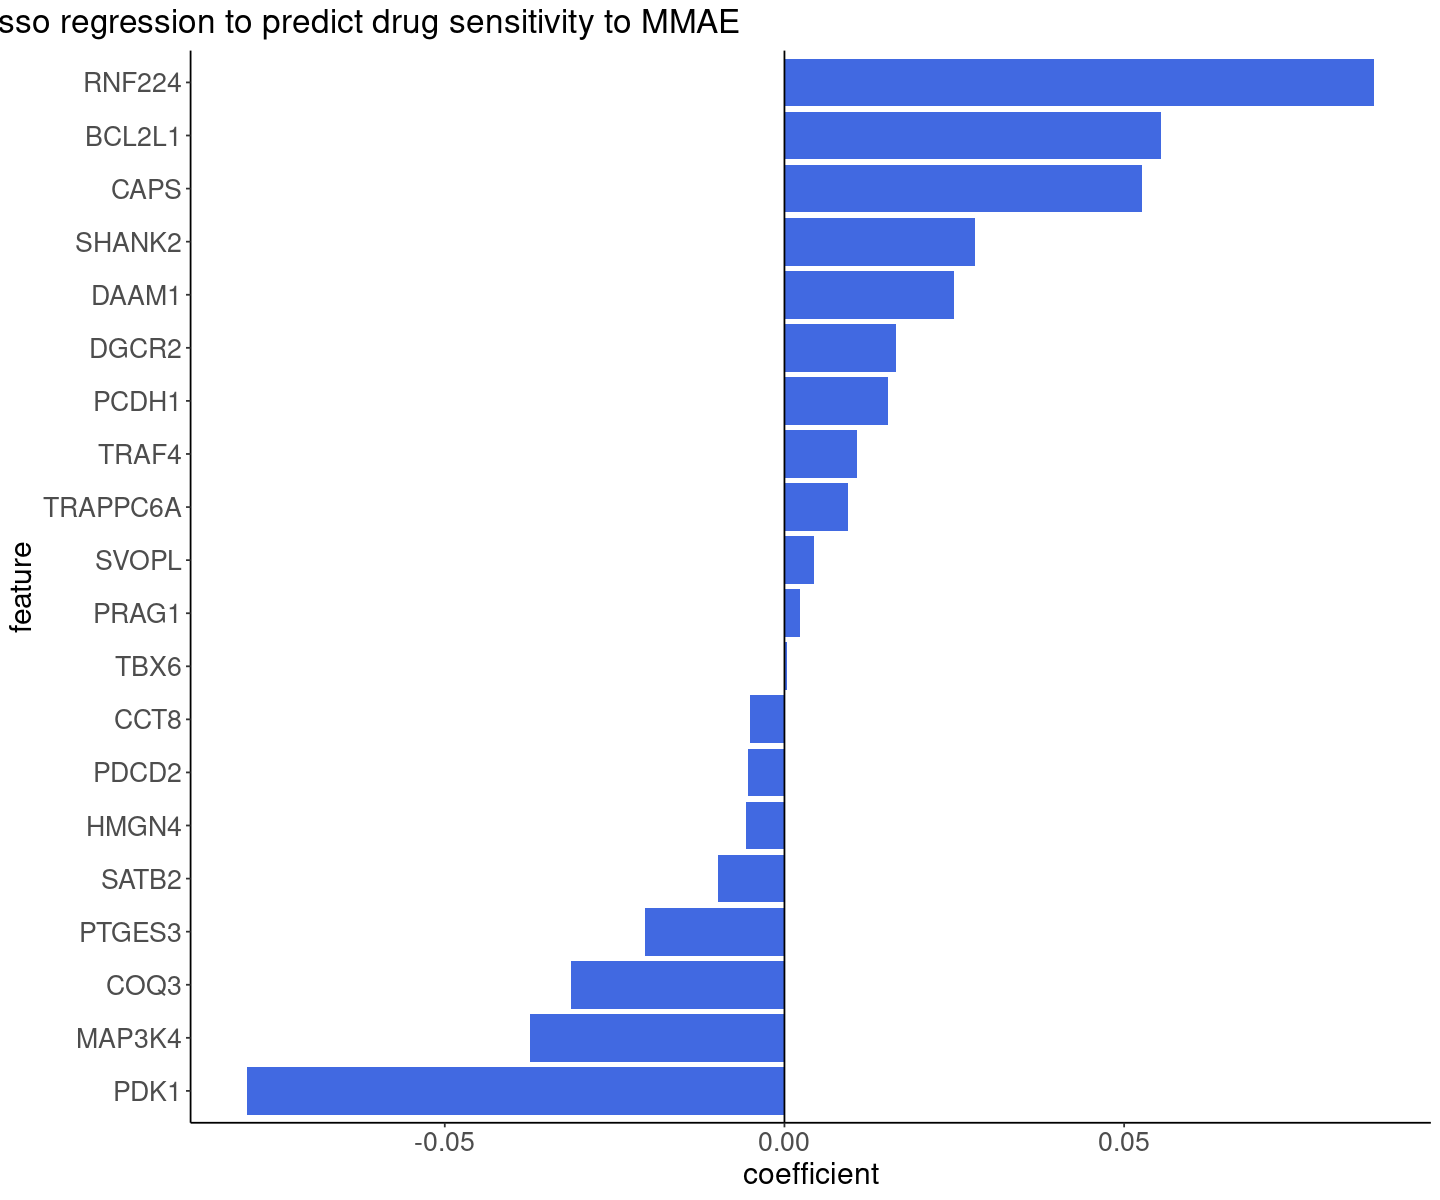

In [86]:

y = as.vector(lasso_df[, 'logFC'])
x=as.matrix(lasso_df[, gene_list])
# scaled.x= x
scaled.x=scale(x)

# https://bookdown.org/gongchangzhaojie/TranslationalBioinformaticsWithR/predictive-biomarkers.html
set.seed(123)                                # replicate  results
# lasso_model <- cv.glmnet(scaled.x, y, alpha=1, type.gaussian = "naive", intercept= TRUE)
# lasso_model <- cv.glmnet(scaled.x, y, alpha=1, intercept= TRUE ,nfolds= 7) 
lasso_model <- cv.glmnet(scaled.x, y, alpha=1) # alpha = 1 lasso
best_lambda_la <- lasso_model$lambda.1se     # largest lambda in 1 SE
lasso_coef <- lasso_model$glmnet.fit$beta[,        # retrieve coefficients
              lasso_model$glmnet.fit$lambda     # at lambda.1se
              == best_lambda_la]
coef_la = data.table(lassoReg = lasso_coef)   # build table
coef_la[, feature := names(lasso_coef)]      # add feature names
to_plot_r_la = melt(coef_la                     # label table
               , id.vars='feature'
               , variable.name = 'model'
               , value.name = 'coefficient')


options(repr.plot.height = 10, repr.plot.width = 12)

to_plot_r_la.2 <- to_plot_r_la %>% filter(coefficient != 0) %>% arrange(coefficient)
to_plot_r_la.2$feature <- factor(to_plot_r_la.2$feature, levels = unique(to_plot_r_la.2$feature))

ggplot(data=to_plot_r_la.2,                       # plot coefficients
       aes(x=feature, y=coefficient)) +
       coord_flip() +         
       geom_bar(stat='identity', fill='royalblue') +
geom_hline(yintercept = 0)+
       # facet_wrap(~ model) + guides(fill=FALSE)  +
labs(title = glue('Lasso regression to predict drug sensitivity to MMAE')) +
theme_classic() +
    theme(axis.text.x = element_text(size = 16),
        axis.text.y = element_text(size = 16),  
        axis.title.x = element_text( size = 18),
        axis.title.y = element_text(size = 18), 
          plot.title = element_text(size=20, hjust = -0.5))

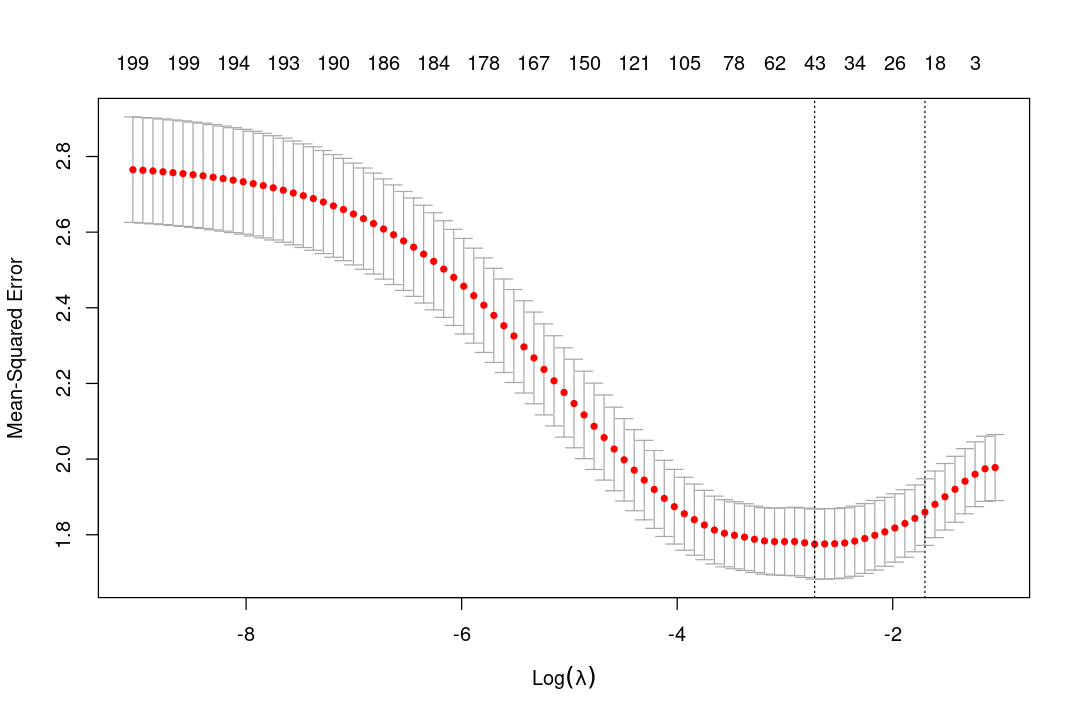

In [87]:
options(repr.plot.height = 6, repr.plot.width = 9)
plot(lasso_model)

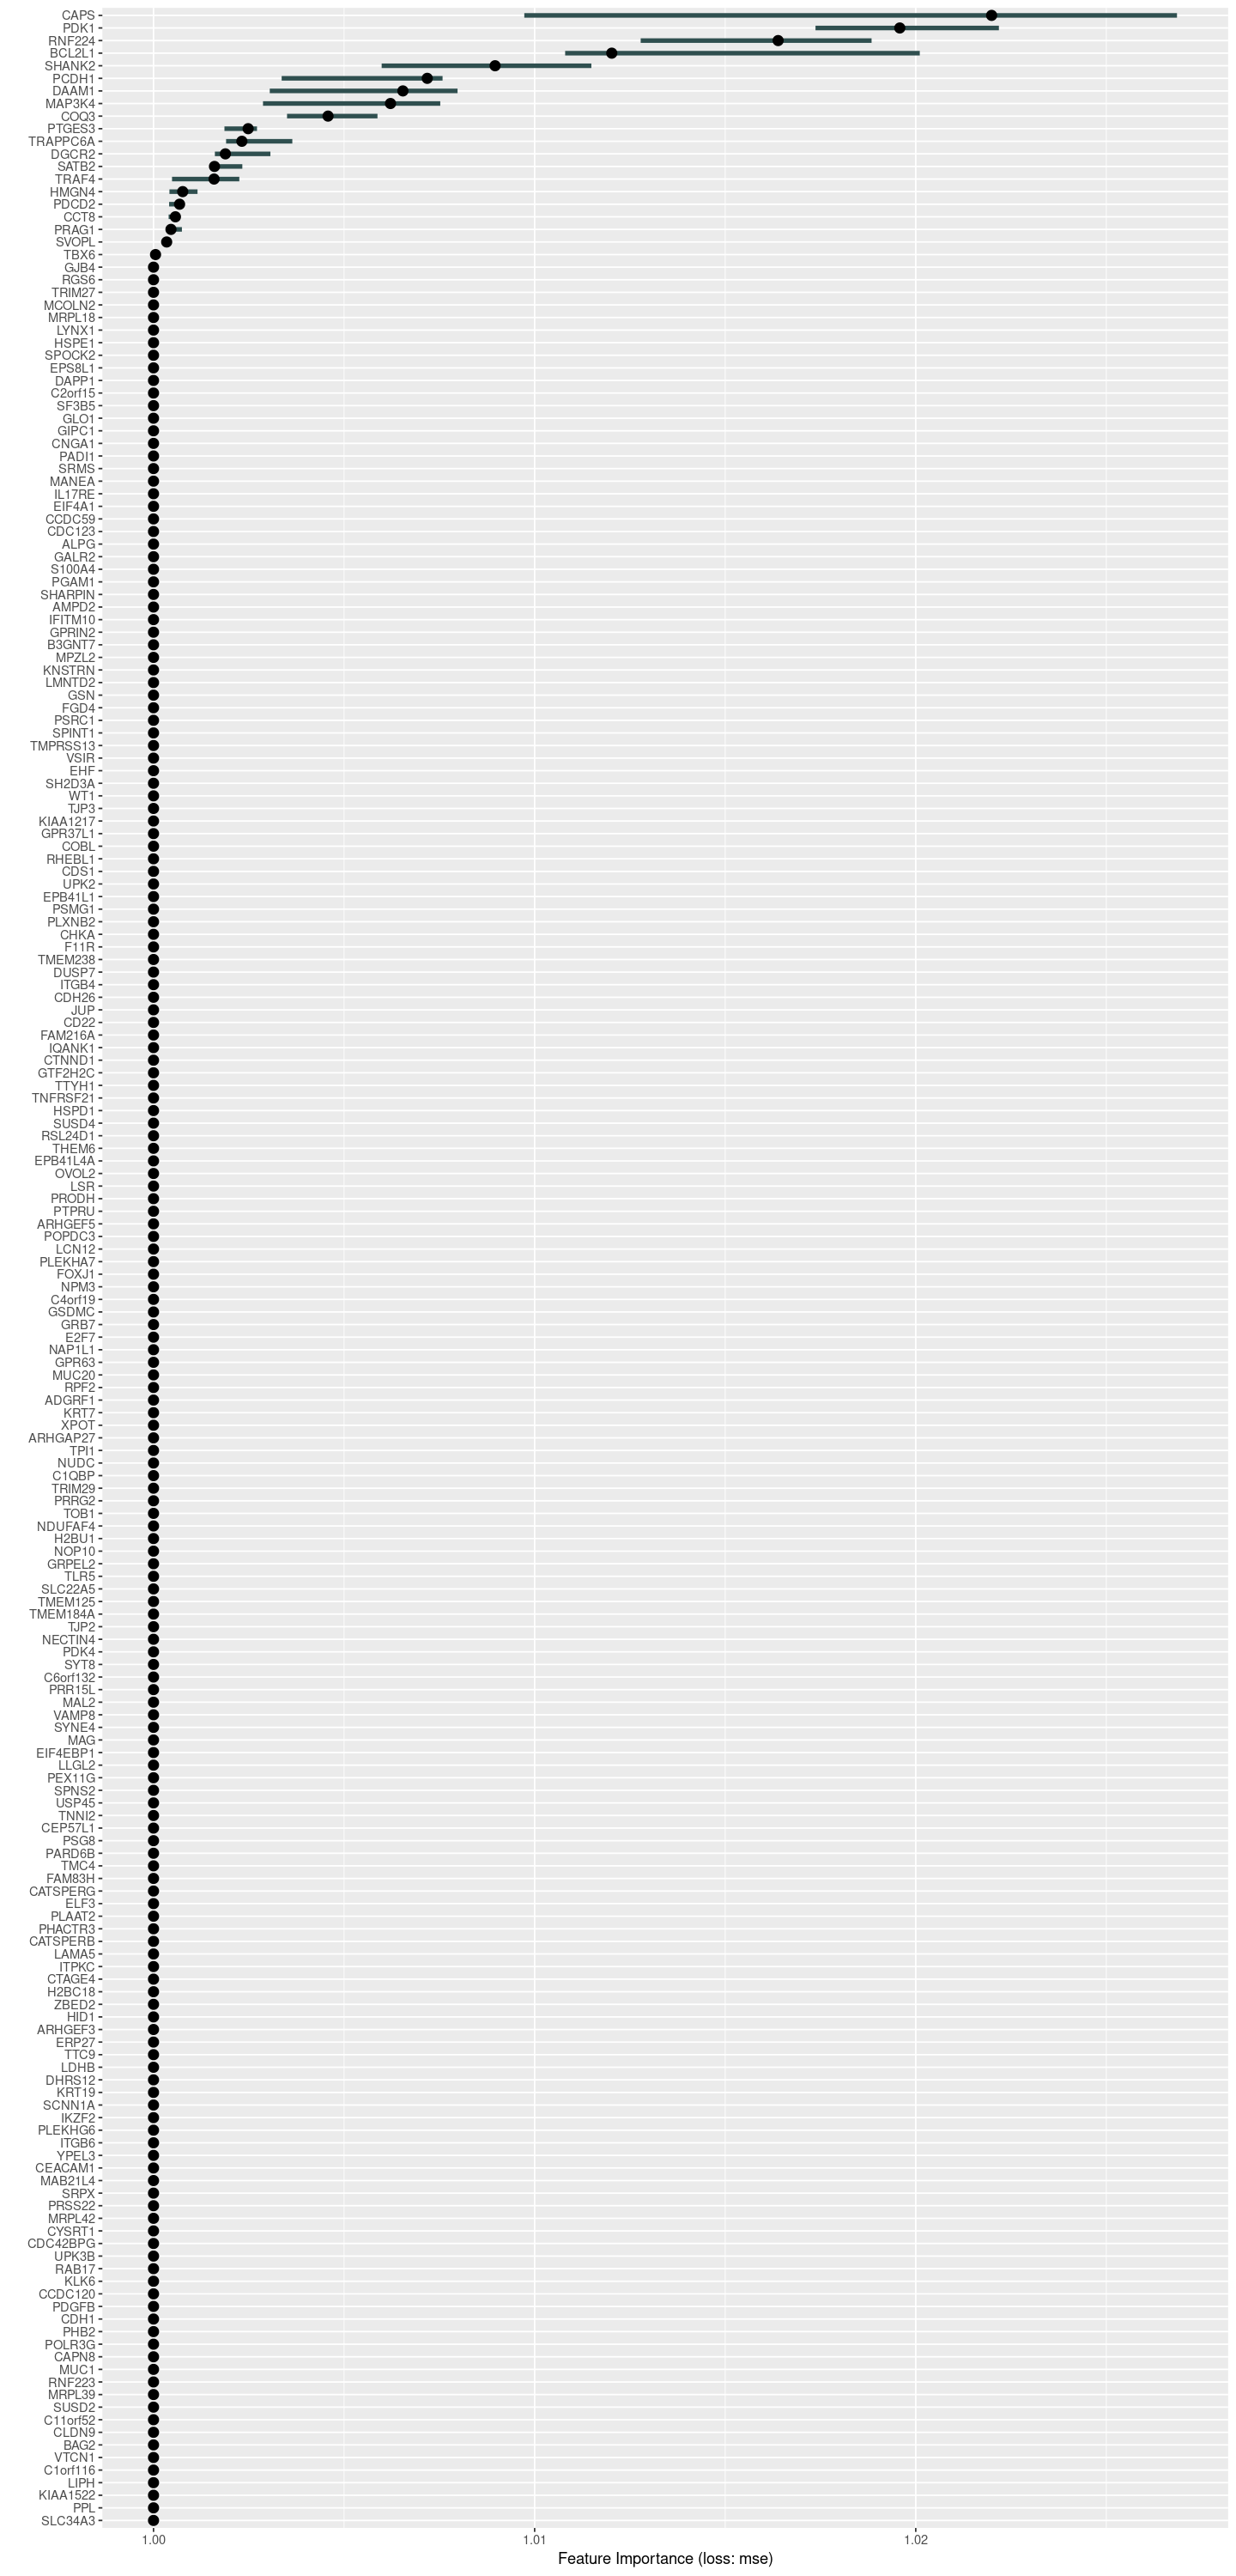

In [88]:
options(warn = -1)
# Conduct global interpretation of the whole model
# https://github.com/christophM/iml/issues/29
##adapted from the github repo above
predict.function <-  function(object, newdata){
newData_x = data.matrix(newdata)
results<-predict(lasso_model, newData_x)
return(results)
}

data1 <- as.data.frame(x)
colnames(data1) <- gene_list

iml_predictor <- Predictor$new(lasso_model, data = data1, y = y,
                           predict.fun = predict.function)
imp_features <- FeatureImp$new(iml_predictor, loss = "mse")

options(repr.plot.height = 25, repr.plot.width = 12)
plot(imp_features)

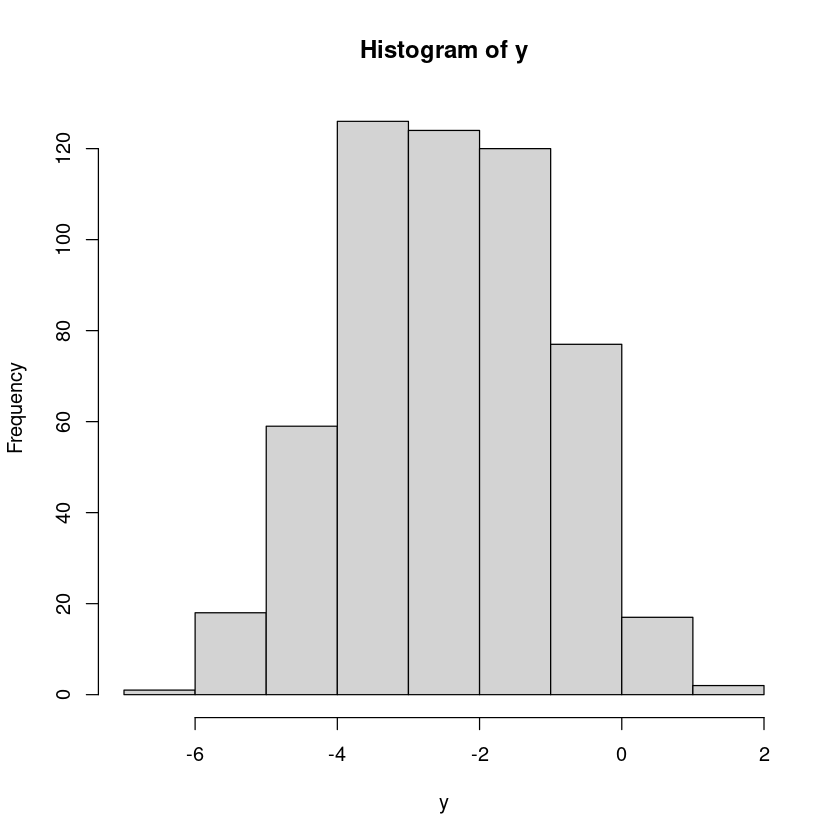

In [89]:
options(repr.plot.width = 7, repr.plot.height = 7)
hist(y)

In [95]:
# smp_lasso_df <- merge(smp_info, lasso_df, by.x = 'DepMap_ID', by.y = 'Row.names')

# most sensitive cell lines
# 1 uM
sensitive_df <- logfc.pheno %>% filter(logFC < -3) 
table(sensitive_df$OncotreePrimaryDisease) %>% sort(decreasing = T)


                                                                         Non-Small Cell Lung Cancer 
                                                                                                 29 
                                                                                     Diffuse Glioma 
                                                                                                 22 
                                                                                           Melanoma 
                                                                                                 18 
                                                                          Colorectal Adenocarcinoma 
                                                                                                 14 
                                                                              Endometrial Carcinoma 
                                                                                          